# Day 3 — Training Dynamics & Optimization

## Note 3.4 — The Diagnosis Clinic

### Learning goal and outcome

Notes 3.1–3.3 gave you three different kinds of diagnostic knowledge:

- **learning-rate and optimisation signatures** — what the training curves say about how the optimiser is moving;
- **generalisation signatures** — what the gap between training and validation tells you about fitting and regularisation;
- **gradient-flow signatures** — what is happening inside the network, layer by layer.

This note turns those separate ideas into a **repeatable diagnostic procedure**.

That distinction matters. It is one thing to know that a very large learning rate can cause collapse. It is another skill entirely to receive an unfamiliar training run, inspect the evidence, identify the most likely failure mode, and choose the cheapest test that can distinguish it from competing explanations.

The goal is therefore not to memorise six answers. The goal is to learn a sequence:

> **observe → compare with a reference → form a hypothesis → test the hypothesis → intervene → verify the fix**

By the end of this note, you will work through six broken experiments from symptom to cause to fix. One is especially important: **the curves look healthy, the diagnostics look healthy, and the model is still unusable**. You will then diagnose two additional cases without an answer key.

### Objectives

By the end of this note, you should be able to:

- recognise six common loss-curve shapes and connect each shape to the evidence that distinguishes it;
- use a config-driven experiment harness so that different runs can be compared fairly;
- apply a diagnostic protocol in **cost order**, starting with checks that require no retraining;
- inspect metrics, prediction distributions, gradient norms, and small-subset memorisation together rather than treating loss as the whole diagnosis;
- distinguish a problem in the **model**, a problem in the **training process**, and a problem in the **experiment/data setup**;
- diagnose and fix six deliberately broken experiments while stating the evidence for the diagnosis;
- recognise that a smooth, plausible training curve is not proof that the model is valid;
- record experiments so that the reasoning can be reconstructed months later.

### Datasets

The notebook uses two datasets, selected through configuration.

- **German Credit** (500/250/250) is used for the training-dynamics and regularisation cases. It is carried forward from Notes 3.2 and 3.3 so that the reference behaviour is familiar.
- **Bank Marketing** (45,211 rows) is used for the leakage case. Its `duration` column records the length of a completed sales call, making it an instructive example of a feature that can be highly predictive while being unavailable at the moment the prediction must actually be made.

The important principle is that a model is only valid relative to its **prediction moment**: a feature that becomes known after the prediction cannot legitimately be used to make that prediction.

### Table of contents

1. [The curve gallery](#s1)
2. [The harness](#s2)
3. [A diagnostic protocol](#s3)
4. [Case 1 — learning rate too high](#s4)
5. [Case 2 — learning rate too low](#s5)
6. [Case 3 — over-regularised](#s6)
7. [Case 4 — broken validation](#s7)
8. [Case 5 — poor initialisation](#s8)
9. [Case 6 — the one that looks fine](#s9)
10. [Your turn](#s10)
11. [Writing it up](#s11)


In [1]:
# torch 2.14.0 | scikit-learn 1.8.0 | numpy 2.4.4 | pandas 3.0.2 | matplotlib 3.10.8
import os, io, json, time, zipfile, urllib.request, copy
import numpy as np, pandas as pd, torch, torch.nn as nn, matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score

DEVICE = torch.device("cpu"); SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
loss_fn = nn.BCEWithLogitsLoss()
os.makedirs("results", exist_ok=True); os.makedirs("data", exist_ok=True)
print("torch", torch.__version__)


torch 2.14.0+cpu


<a id="s1"></a>
## 1. The curve gallery

Before diagnosing a run, establish a visual vocabulary.

The plot produced by the next code cell contains six representative training/validation loss patterns drawn from the behaviours explored in Notes 3.1–3.3. They are not merely shapes to memorise: each shape is a **symptom**, and the rest of the diagnostics tell you which underlying cause produced it.

Keep this output visible while working through the cases.

When reading a training curve, ask three questions in order:

1. **Is the loss moving at all?**
2. **Are training and validation behaving differently?**
3. **Does the metric and prediction behaviour agree with the story suggested by the loss?**

The third question is essential. Loss is an optimisation quantity; it is not automatically a measure of whether the trained model is useful.

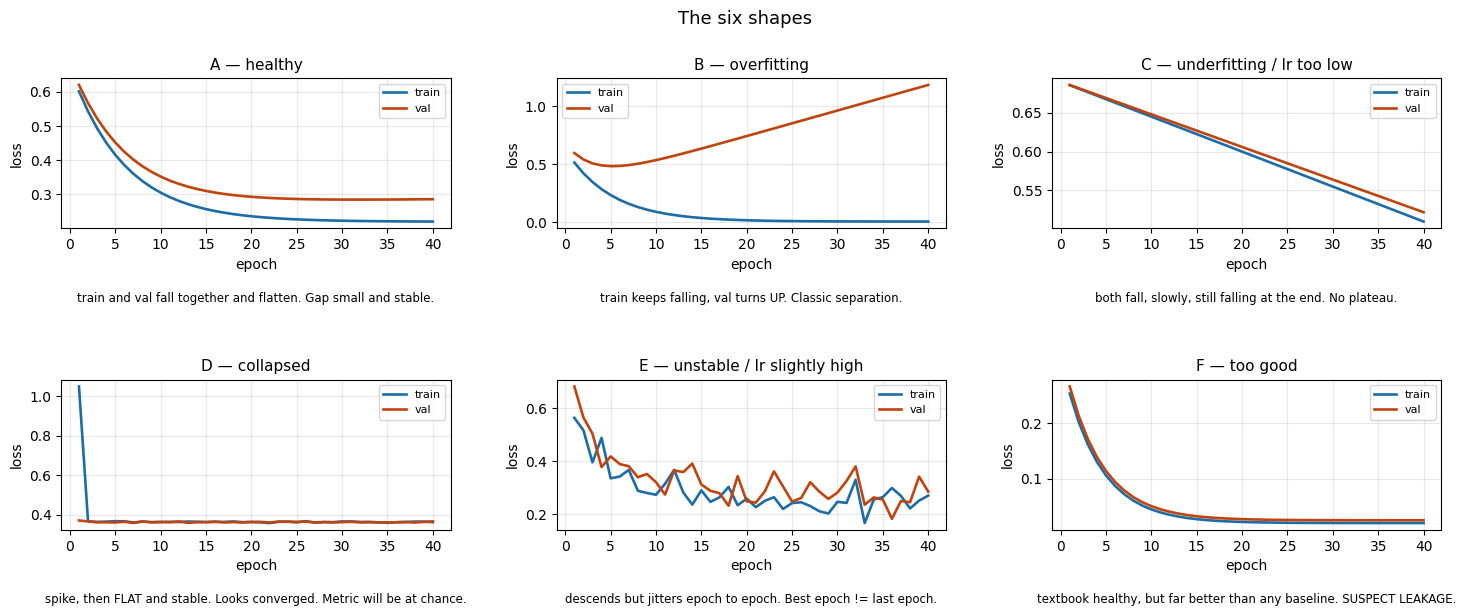

In [2]:
e = np.arange(1, 41)
gallery = {
    "A — healthy": (
        0.22 + 0.45*np.exp(-e/6), 0.26 + 0.42*np.exp(-e/6) + 0.004*np.sqrt(e),
        "train and val fall together and flatten. Gap small and stable."),
    "B — overfitting": (
        0.62*np.exp(-e/5) + 0.005, 0.30 + 0.38*np.exp(-e/3) + 0.022*e,
        "train keeps falling, val turns UP. Classic separation."),
    "C — underfitting / lr too low": (
        0.69 - 0.0045*e, 0.69 - 0.0042*e,
        "both fall, slowly, still falling at the end. No plateau."),
    "D — collapsed": (
        np.concatenate([[1.05], np.full(39, 0.362) + 0.002*np.random.RandomState(0).randn(39)]),
        np.concatenate([[0.37], np.full(39, 0.362) + 0.002*np.random.RandomState(1).randn(39)]),
        "spike, then FLAT and stable. Looks converged. Metric will be at chance."),
    "E — unstable / lr slightly high": (
        0.25 + 0.40*np.exp(-e/5) + 0.035*np.random.RandomState(2).randn(40),
        0.29 + 0.38*np.exp(-e/5) + 0.045*np.random.RandomState(3).randn(40),
        "descends but jitters epoch to epoch. Best epoch != last epoch."),
    "F — too good": (
        0.30*np.exp(-e/4) + 0.02, 0.31*np.exp(-e/4) + 0.025,
        "textbook healthy, but far better than any baseline. SUSPECT LEAKAGE."),
}
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (name, (tr, va, note)) in zip(axes.ravel(), gallery.items()):
    ax.plot(e, tr, lw=1.9, color="#1b6ca8", label="train")
    ax.plot(e, va, lw=1.9, color="#c1440e", label="val")
    ax.set_title(name, fontsize=11); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.text(0.5, -0.42, note, transform=ax.transAxes, ha="center", va="top",
            fontsize=8.5, wrap=True)
plt.suptitle("The six shapes", y=1.0, fontsize=13)
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()


Three of these shapes are especially easy to misread. Commit the *reasoning* behind them to memory rather than memorising the letters.

**D looks like success.** A flat, stable loss usually means the optimiser has converged. But convergence only means that the optimisation has stopped making meaningful progress. A model can converge to a useful solution or to a trivial one. The distinguishing evidence is therefore the **metric and the prediction distribution**, not the fact that the loss is flat.

**C looks like a hard problem.** A slowly descending curve can tempt you to conclude that the data is weak or the model lacks capacity. But if the curve is still descending when the epoch budget ends, the experiment may simply be **undertrained**. You have measured how far the optimiser got, not the performance the model would reach if it had enough training.

**F looks like a triumph.** An unexpectedly excellent result is not automatically evidence that the model is excellent. It can be evidence that the experiment is broken — for example through validation leakage or target leakage. A result that is dramatically better than a sensible baseline should trigger an investigation into *why* before it triggers celebration.

<div align="center">

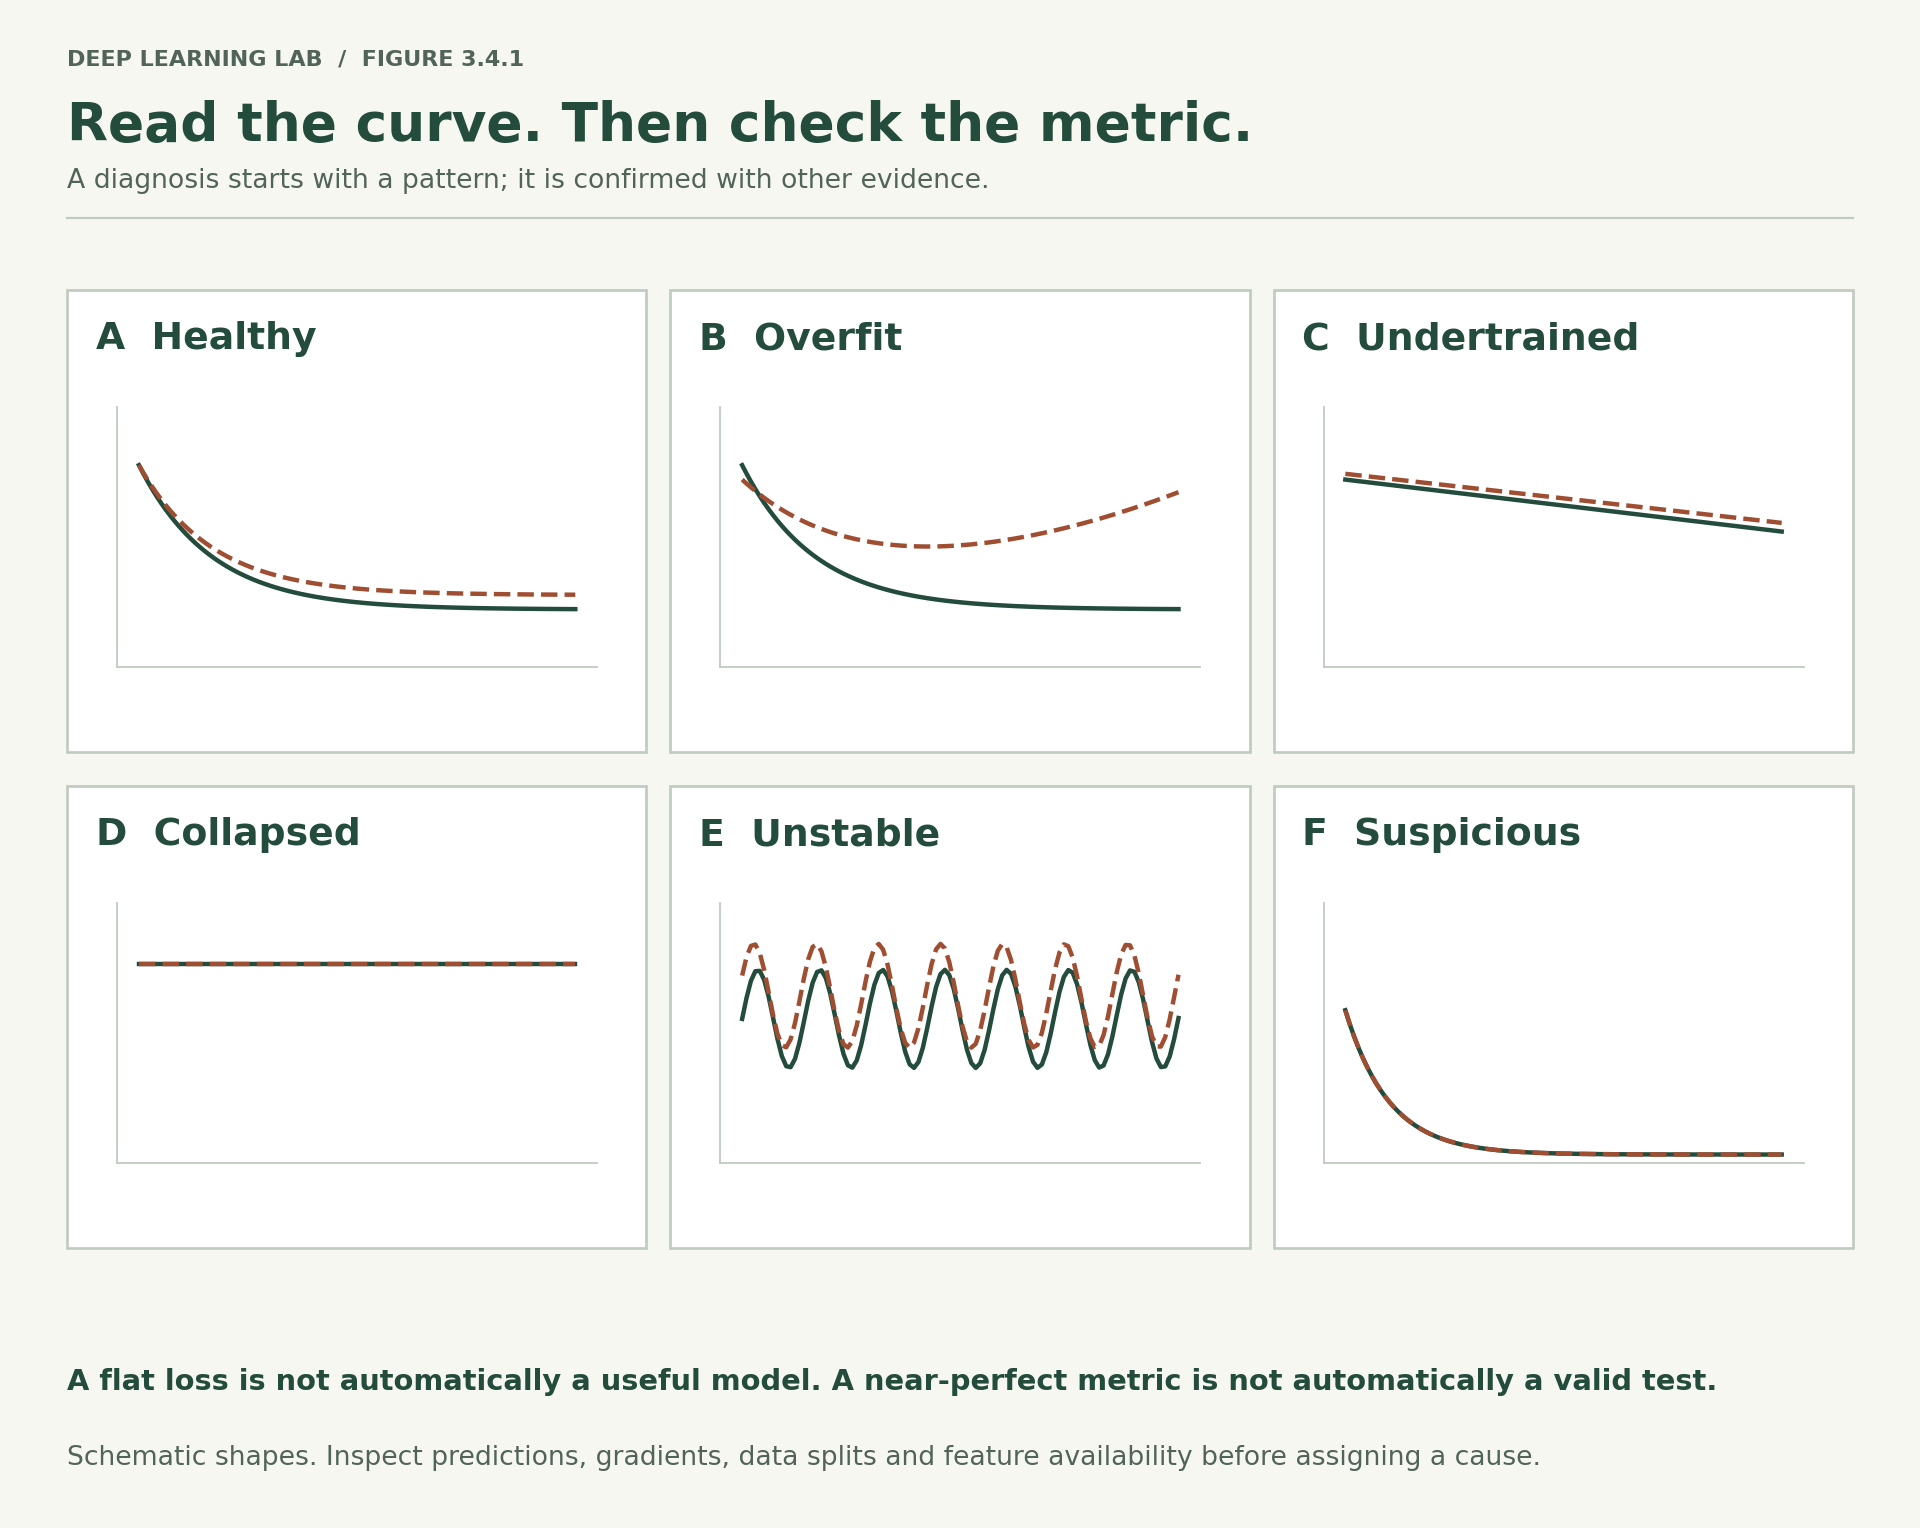

<p><b>Figure 3.4.1.</b> Six illustrative signatures support the diagnosis gallery. Training is solid green; validation is dashed rust. Shapes suggest questions, not a definitive cause.</p>

</div>

**Check your understanding**

1. Shapes C and D both end with a curve that stops moving. What evidence, other than the loss itself, distinguishes them? Explain why a flat loss is compatible with both healthy convergence and collapse.
2. Shape F is described as dangerous. Why can an apparently excellent result be evidence that you should investigate the experiment rather than trust the model?
3. You see shape E and the final-epoch score is worse than the best-epoch score. What does that tell you about the relationship between the current checkpoint and the best checkpoint, and what stopping/checkpointing behaviour should you consider?

<a id="s2"></a>
## 2. The harness

Day 2, Note 2.4 ended by extracting the notebook into a project repository with a **config-driven entry point**:

```text
python -m src.training.train --config configs/baseline.yaml
```

The important idea is that the experiment's settings live in a configuration rather than being scattered through the training code. The runner can therefore execute the same pipeline repeatedly while changing a controlled set of values.

That is exactly what we need here. Six diagnostic cases are only useful if the underlying pipeline stays the same. Otherwise, when a result changes, you cannot tell which change caused it.

This notebook extends the earlier harness in two ways:

1. it supports both datasets, selected through a configuration key; and
2. it records **per-layer gradient norms** from Note 3.3 alongside the loss and metric history.

A run therefore carries several kinds of evidence:

- **loss history** — how optimisation progressed;
- **validation metrics** — whether the model's behaviour is useful on held-out data;
- **prediction summaries** — whether the model is producing varied, informative outputs;
- **gradient profiles** — whether different parts of the network are receiving a usable learning signal;
- **configuration** — exactly what settings produced the run.

This is what makes the later diagnosis reproducible rather than anecdotal.

In [3]:
# ---------------------------------------------------------------- data loading
def load_bank_marketing(include_duration=False):
    CSV = "data/bank-full.csv"
    if not os.path.exists(CSV):
        url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
        raw = urllib.request.urlopen(url, timeout=120).read()
        outer = zipfile.ZipFile(io.BytesIO(raw))
        inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
        open(CSV, "wb").write(inner.read("bank-full.csv"))
    df = pd.read_csv(CSV, sep=";")
    y = (df["y"] == "yes").astype(np.float32).values
    drop = ["y"] if include_duration else ["y", "duration"]
    return df.drop(columns=drop), y

def load_german_credit():
    d = fetch_openml("credit-g", version=1, as_frame=True)
    return d.data.copy(), (d.target == "bad").astype(np.float32).values

def prepare(cfg):
    """Build tensors from a config. `leak_split` deliberately breaks the split."""
    name = cfg.get("dataset", "german_credit")
    if name == "german_credit":
        X, y = load_german_credit(); train_size = 500
    else:
        X, y = load_bank_marketing(include_duration=cfg.get("include_duration", False))
        train_size = 0.8
    num = X.select_dtypes(include="number").columns.tolist()
    cat = [c for c in X.columns if c not in num]

    Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, train_size=train_size,
                                            random_state=SEED, stratify=y)
    Xva, _, yva, _ = train_test_split(Xtmp, ytmp, test_size=0.5, random_state=SEED, stratify=ytmp)

    if cfg.get("leak_split", False):
        # BUG: validation rows are drawn from the training rows.
        n = len(Xva)
        Xva, yva = Xtr.iloc[:n].copy(), ytr[:n].copy()

    pre = ColumnTransformer([("n", StandardScaler(), num),
                             ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)])
    A = pre.fit_transform(Xtr).astype(np.float32)
    V = pre.transform(Xva).astype(np.float32)
    return (torch.tensor(A), torch.tensor(ytr).unsqueeze(1),
            torch.tensor(V), torch.tensor(yva).unsqueeze(1), ytr, yva, A.shape[1])


In [4]:
# ------------------------------------------------------------------- the model
def build_model(cfg, d_in):
    torch.manual_seed(cfg.get("seed", SEED))
    hidden = tuple(cfg.get("hidden", (64, 32)))
    p = cfg.get("dropout", 0.0)
    layers, prev = [], d_in
    for h in hidden:
        layers += [nn.Linear(prev, h), nn.ReLU()]
        if p > 0: layers.append(nn.Dropout(p))
        prev = h
    layers.append(nn.Linear(prev, 1))
    model = nn.Sequential(*layers)
    init = cfg.get("init", "default")
    if init != "default":
        for mod in model:
            if isinstance(mod, nn.Linear):
                if init == "zeros":
                    nn.init.zeros_(mod.weight); nn.init.zeros_(mod.bias)
                elif init == "big":
                    nn.init.normal_(mod.weight, 0.0, float(cfg.get("init_std", 3.0)))
                    nn.init.zeros_(mod.bias)
    return model

def layer_grad_norms(model, xb, yb):
    """The Note 3.3 probe, returned as a plain dict so it serialises to JSON."""
    model.train(); model.zero_grad()
    loss_fn(model(xb), yb).backward()
    out = {n: p.grad.norm().item() for n, p in model.named_parameters()
           if p.grad is not None and p.dim() > 1}
    model.zero_grad()
    return out


[baseline] german_credit  0.7s   final val AUC 0.7245   best val AUC 0.8158


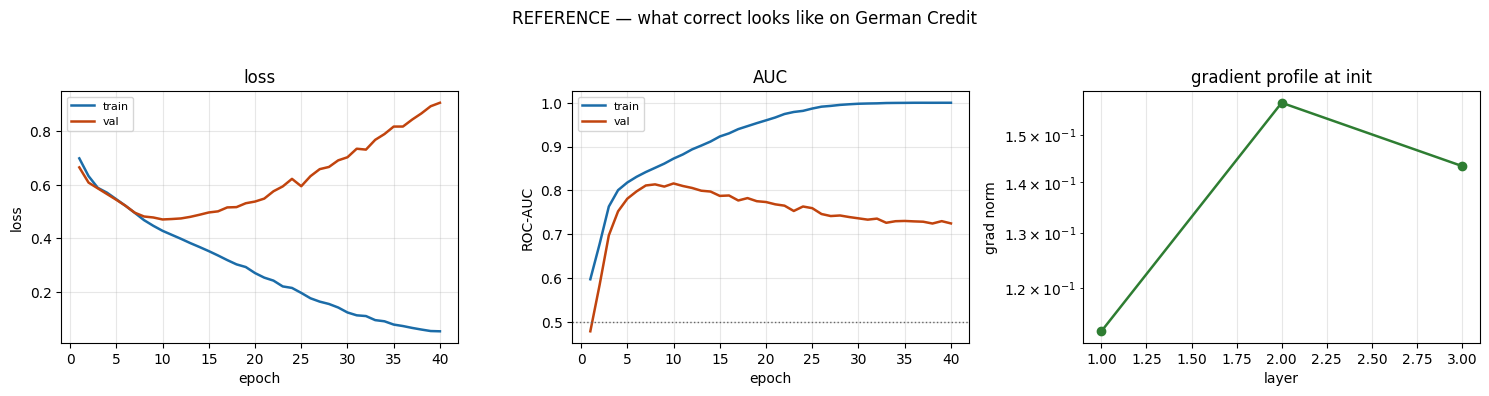

In [5]:
# ----------------------------------------------------------------- the runner
def run_experiment(cfg, save=True, quiet=False):
    """The Day 2 config runner, extended with per-layer gradient logging."""
    Xt, Yt, Xv, Yv, ytr, yva, d_in = prepare(cfg)
    model = build_model(cfg, d_in)
    opt = torch.optim.AdamW(model.parameters(),
                            lr=cfg.get("lr", 1e-3),
                            weight_decay=cfg.get("weight_decay", 0.0))
    g = torch.Generator().manual_seed(cfg.get("seed", SEED))
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xt, Yt),
        batch_size=cfg.get("batch_size", 32), shuffle=True, generator=g)

    probe_x, probe_y = Xt[:256], Yt[:256]
    grads_at_start = layer_grad_norms(model, probe_x, probe_y)

    history, t0 = [], time.time()
    for ep in range(1, cfg.get("epochs", 40) + 1):
        model.train()
        tot = n = 0
        for xb, yb in loader:
            opt.zero_grad(); l = loss_fn(model(xb), yb); l.backward()
            if cfg.get("clip"): nn.utils.clip_grad_norm_(model.parameters(), cfg["clip"])
            opt.step(); tot += l.item()*len(xb); n += len(xb)
        model.eval()
        with torch.no_grad():
            a, b = model(Xt), model(Xv)
            pa = torch.sigmoid(a).numpy().ravel(); pb = torch.sigmoid(b).numpy().ravel()
        history.append(dict(
            epoch=ep, train_loss=tot/n, val_loss=loss_fn(b, Yv).item(),
            train_auc=float(roc_auc_score(ytr, pa)), val_auc=float(roc_auc_score(yva, pb)),
            val_acc=float(accuracy_score(yva, pb > 0.5))))

    model.eval()
    with torch.no_grad():
        pb = torch.sigmoid(model(Xv)).numpy().ravel()
    result = dict(
        config=cfg, history=history,
        grads_at_start=grads_at_start,
        grad_ratio=(list(grads_at_start.values())[-1] / max(list(grads_at_start.values())[0], 1e-30)),
        final=history[-1],
        best_val_loss=min(h["val_loss"] for h in history),
        best_val_auc=max(h["val_auc"] for h in history),
        majority_acc=float(max(yva.mean(), 1-yva.mean())),
        pred_min=float(pb.min()), pred_max=float(pb.max()), pred_std=float(pb.std()),
        n_unique_preds=int(len(np.unique(pb.round(4)))),
        seconds=time.time()-t0)
    if save:
        with open(f"results/{cfg.get('name','run')}.json", "w") as f:
            json.dump(result, f, indent=2)
    if not quiet:
        print(f"[{cfg.get('name','run')}] {cfg.get('dataset','german_credit')}  "
              f"{result['seconds']:.1f}s   final val AUC {result['final']['val_auc']:.4f}   "
              f"best val AUC {result['best_val_auc']:.4f}")
    return result

def show(result, title=None):
    h = result["history"]; e = [x["epoch"] for x in h]
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    axes[0].plot(e, [x["train_loss"] for x in h], label="train", color="#1b6ca8", lw=1.8)
    axes[0].plot(e, [x["val_loss"] for x in h], label="val", color="#c1440e", lw=1.8)
    axes[0].set_ylabel("loss"); axes[0].set_title("loss")
    axes[1].plot(e, [x["train_auc"] for x in h], label="train", color="#1b6ca8", lw=1.8)
    axes[1].plot(e, [x["val_auc"] for x in h], label="val", color="#c1440e", lw=1.8)
    axes[1].axhline(0.5, ls=":", c="0.4", lw=1); axes[1].set_ylabel("ROC-AUC"); axes[1].set_title("AUC")
    gn = list(result["grads_at_start"].values())
    axes[2].plot(range(1, len(gn)+1), gn, "o-", color="#2e7d32", lw=1.8)
    axes[2].set_yscale("log"); axes[2].set_xlabel("layer"); axes[2].set_ylabel("grad norm")
    axes[2].set_title("gradient profile at init")
    for a in axes[:2]: a.set_xlabel("epoch"); a.legend(fontsize=8)
    for a in axes: a.grid(alpha=0.3)
    plt.suptitle(title or result["config"].get("name",""), y=1.03)
    plt.tight_layout(); plt.show()

BASELINE = dict(name="baseline", dataset="german_credit", hidden=(64,32),
                lr=1e-3, epochs=40, batch_size=32)
ref = run_experiment(BASELINE)
show(ref, "REFERENCE — what correct looks like on German Credit")


That is the **reference run**: the example of what normal behaviour looks like when the same pipeline is configured sensibly.

Every case below changes **one key** in the configuration unless the section explicitly says otherwise. Keep the reference numbers visible while you work. The reference has a final validation AUC around 0.74 and a best validation AUC around 0.82, on a dataset where majority-class accuracy is 0.70 and published results are reported around 0.78–0.80 AUC.

These values are not universal targets. They are a **local reference** for this exact dataset, split, preprocessing pipeline, model family, and evaluation setup.

That is what a baseline is for. Diagnosis is fundamentally comparative: you cannot call a run abnormal unless you know what normal looks like under the same experimental conditions.

A useful mental model is:

> **Baseline = your control condition.**

If the baseline changes every time you diagnose a problem, you lose the ability to attribute differences to the suspected fault.

<a id="s3"></a>
## 3. A diagnostic protocol

When a training run looks wrong, the tempting response is to change something plausible and run it again. That is **search**, not diagnosis.

Search can eventually find a working configuration, but it does not necessarily tell you why the original run failed. It is also expensive: every retraining attempt consumes time and introduces another result that must be interpreted.

The protocol below is therefore ordered by **cost**, not by how interesting a test feels.

### Tier 0 — free checks, before retraining

These use information already produced by the run.

1. **Are the losses finite?**  
   If the loss is `NaN` or `Inf`, downstream metrics and comparisons cannot be trusted.

2. **What is the metric doing?**  
   A stable loss with AUC near chance can indicate that the model has converged to a useless solution rather than a useful one.

3. **What do the predictions look like?**  
   Inspect their minimum, maximum, spread, and number of distinct values. A model producing essentially one value has collapsed. A model producing only a narrow band of probabilities may be heavily regularised or otherwise unable to separate decisions.

4. **Is the result implausibly better than a sensible baseline?**  
   If yes, investigate leakage before interpreting the number as genuine model quality.

### Tier 1 — one forward/backward pass

These require looking inside the model, but do not require a full retraining run.

5. **Total gradient norm.**  
   Extremely large gradients suggest explosion; extremely small gradients can indicate that the learning signal has disappeared.

6. **Per-layer gradient profile.**  
   Compare gradient magnitudes across layers. If one part of a network receives much less signal than another, the network may not be training uniformly.

7. **Dead-unit fraction.**  
   For ReLU networks, inspect how many units are persistently inactive.

### Tier 2 — checks that require another run

8. **Can the model overfit a tiny subset?**  
   Take 20 rows and deliberately train until the loss is near zero. A model that cannot memorise a tiny, fixed dataset has a structural problem somewhere in the model, data pipeline, or loss. This is one of the highest-value debugging tests because it sharply narrows the search.

9. **Learning-rate sweep.**  
   Test learning rates across orders of magnitude rather than nudging the value blindly.

10. **Regularisation and capacity changes.**  
    Only after the earlier evidence points in this direction should you change dropout, weight decay, width, depth, or related capacity controls.

The ordering is deliberate. The expensive checks are often the ones that *feel* most productive, but the cheap checks can eliminate whole classes of explanations before you spend another training cycle.

In [6]:
def tier0(result, name=""):
    """The free checks. No retraining."""
    f = result["final"]
    print(f"--- Tier 0: {name} ---")
    print(f"  final train loss / val loss : {f['train_loss']:.4f} / {f['val_loss']:.4f}")
    print(f"  finite?                     : {np.isfinite(f['train_loss']) and np.isfinite(f['val_loss'])}")
    print(f"  final val AUC               : {f['val_auc']:.4f}   (chance = 0.5000)")
    print(f"  best  val AUC               : {result['best_val_auc']:.4f}")
    print(f"  final val accuracy          : {f['val_acc']:.4f}   (majority = {result['majority_acc']:.4f})")
    print(f"  predictions: min {result['pred_min']:.4f}  max {result['pred_max']:.4f}  "
          f"std {result['pred_std']:.3e}  distinct {result['n_unique_preds']}")
    print(f"  grad ratio last/first       : {result['grad_ratio']:.3e}")

def overfit_tiny(cfg, n=20, epochs=200):
    """Tier 2 check 8: can this setup memorise 20 rows?"""
    Xt, Yt, *_ = prepare(cfg)
    Xs, Ys = Xt[:n], Yt[:n]
    model = build_model(cfg, Xt.shape[1])
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.get("lr", 1e-3))
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xs), Ys).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        final = loss_fn(model(Xs), Ys).item()
    verdict = "PASS - setup can learn" if final < 0.05 else "FAIL - bug in model/data/loss"
    print(f"  overfit-{n}-rows check: final loss {final:.5f}   -> {verdict}")
    return final

tier0(ref, "reference")
overfit_tiny(BASELINE)


--- Tier 0: reference ---
  final train loss / val loss : 0.0551 / 0.9040
  finite?                     : True
  final val AUC               : 0.7245   (chance = 0.5000)
  best  val AUC               : 0.8158
  final val accuracy          : 0.7160   (majority = 0.7000)
  predictions: min 0.0000  max 0.9992  std 3.638e-01  distinct 205
  grad ratio last/first       : 1.274e+00
  overfit-20-rows check: final loss 0.00162   -> PASS - setup can learn


0.00162329594604671

The reference run passes the protocol:

- losses remain finite;
- AUC is clearly above chance;
- accuracy is above the majority-class rate;
- predictions span a wide range and contain hundreds of distinct values;
- the gradient profile is reasonably flat across layers; and
- the model can memorise 20 rows when explicitly asked to do so.

That gives us a concrete picture of **normal**.

The six cases that follow each violate a different part of that picture. Your job is not to spot the answer from the section title. First inspect the evidence, then state the diagnosis, then use the proposed fix to test whether the diagnosis was actually correct.

**Check your understanding**

1. The protocol is ordered by cost rather than by likelihood. Explain how a cheap test can save time even when it does not directly identify the fault.
2. The reference predictions span 0.0000 to 0.9992 with 205 distinct values. Which later faults would that single observation make less likely, and why?
3. `overfit_tiny` is in Tier 2 rather than Tier 1. What additional cost does it introduce, and what structural question does failure to memorise 20 rows answer that a Tier 0 prediction summary cannot?

<a id="s4"></a>
## 4. Case 1 — learning rate too high

Each case uses the same diagnostic structure:

1. inspect the evidence;
2. state the most likely diagnosis;
3. explain the mechanism that connects the evidence to the diagnosis;
4. change the configuration in the smallest defensible way;
5. verify that the result improves.

Before reading the diagnosis below the output, pause and make your own statement of the evidence. The important skill is not guessing the answer; it is being able to justify it.

[case1] german_credit  0.6s   final val AUC 0.5029   best val AUC 0.5134


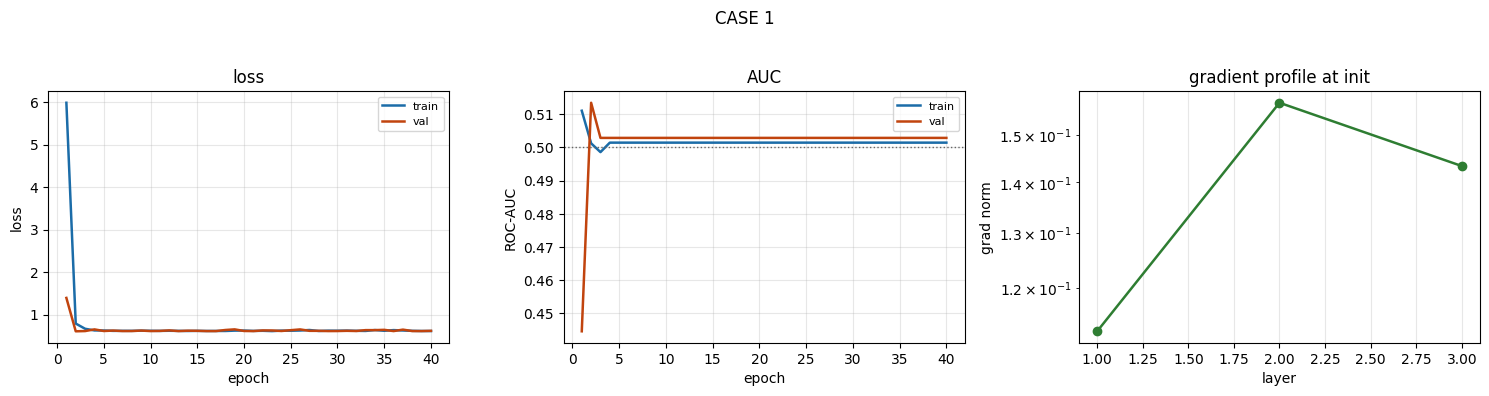

--- Tier 0: case 1 ---
  final train loss / val loss : 0.6116 / 0.6158
  finite?                     : True
  final val AUC               : 0.5029   (chance = 0.5000)
  best  val AUC               : 0.5134
  final val accuracy          : 0.7000   (majority = 0.7000)
  predictions: min 0.2018  max 0.3505  std 9.388e-03  distinct 2
  grad ratio last/first       : 1.274e+00


In [7]:
case1 = run_experiment({**BASELINE, "name": "case1", "lr": 0.5})
show(case1, "CASE 1")
tier0(case1, "case 1")


**Evidence.** This is gallery shape D: the loss settles into a flat, stable line. The final loss is 0.6158, close to 0.6109, the loss obtained by a constant prediction at the dataset base rate. That is a crucial clue: the loss has not merely stopped improving; it has settled near the loss of the **trivial constant predictor**.

The validation AUC is at chance, validation accuracy equals the majority-class rate, and the prediction summary is decisive: only two distinct values occur across 250 validation rows, in a narrow range, with a standard deviation far smaller than the reference run.

This is worth distinguishing from the more extreme collapse shown in Note 3.1 §6, where every prediction became literally identical. Collapse is a continuum. A model can retain a tiny amount of variation while still having lost almost all useful predictive behaviour.

**Diagnosis.** The model has **collapsed to an almost-constant predictor**. The learning rate is too large, so the parameter updates are too aggressive. As discussed in Note 3.3, a sufficiently large update can push many first-layer ReLU units into inactive regions. Once those units stop receiving useful gradients, the network can become effectively unable to recover during the run.

**Why the loss misleads.** Binary cross-entropy has a simple trivial solution: if the model knows only the overall positive rate, predicting that rate for everyone minimises the loss among constant predictions. Therefore a collapsed classifier can have a smooth, stable, apparently "converged" loss.

The important distinction is:

> **convergence means the optimisation has stopped changing the solution; it does not mean the solution is useful.**

That is why the metric and prediction distribution are more informative here than the flat loss curve.

**Fix.** Reduce the learning rate and retrain from the beginning. Once the network has collapsed, simply changing the learning rate after the fact does not undo the parameter trajectory or restore units that have become inactive.

In [8]:
fix1 = run_experiment({**BASELINE, "name": "case1_fixed", "lr": 1e-3})
print(f"\n  before: val AUC {case1['final']['val_auc']:.4f}, "
      f"{case1['n_unique_preds']} distinct predictions")
print(f"  after : val AUC {fix1['final']['val_auc']:.4f}, "
      f"{fix1['n_unique_preds']} distinct predictions")


[case1_fixed] german_credit  0.6s   final val AUC 0.7245   best val AUC 0.8158

  before: val AUC 0.5029, 2 distinct predictions
  after : val AUC 0.7245, 205 distinct predictions


**Check your understanding**

1. Case 1's final validation loss is 0.6158, while a constant prediction at the base rate scores 0.6109. What does that near-match tell you? Why does it make the loss the least informative part of the Tier 0 evidence in this case?
2. Only two distinct predictions appear across 250 validation rows, spanning 0.2018 to 0.3505. Why is such a narrow, near-constant range evidence of collapse rather than evidence that the model is simply "confident"?
3. The fix requires retraining from scratch. Why cannot lowering the learning rate after the collapse simply recover the useful learning trajectory?

<a id="s5"></a>
## 5. Case 2 — learning rate too low

This case demonstrates the opposite problem.

A learning rate is the scale factor that controls how far the optimiser moves the parameters in response to the gradient. If it is too large, updates can overshoot or destabilise training. If it is too small, training may remain perfectly stable while making too little progress within the available epoch budget.

That second failure is easy to miss because almost everything looks "healthy." 

[case2] german_credit  0.6s   final val AUC 0.7803   best val AUC 0.7803


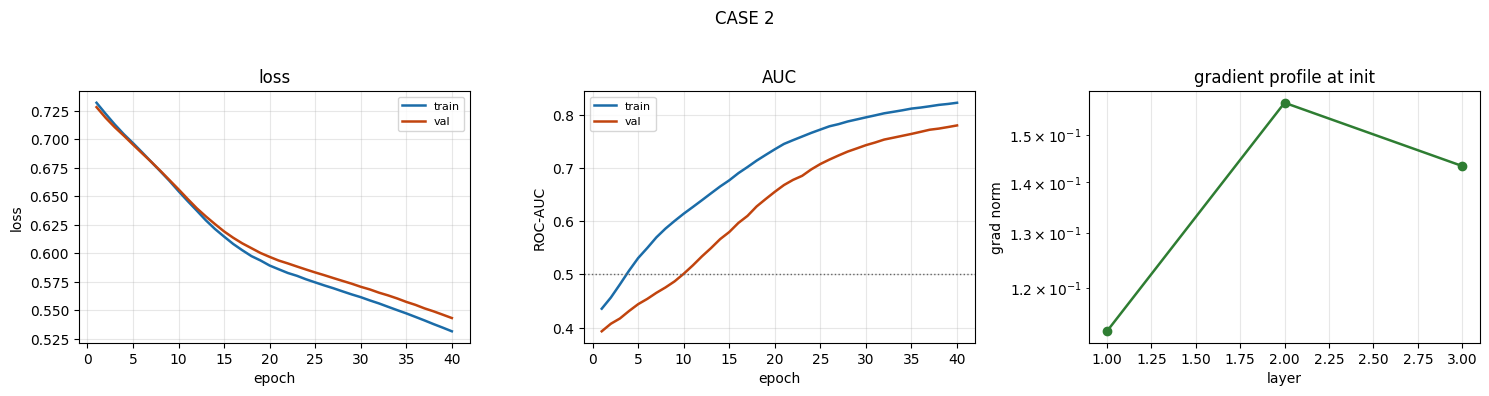

--- Tier 0: case 2 ---
  final train loss / val loss : 0.5316 / 0.5432
  finite?                     : True
  final val AUC               : 0.7803   (chance = 0.5000)
  best  val AUC               : 0.7803
  final val accuracy          : 0.7040   (majority = 0.7000)
  predictions: min 0.1096  max 0.5472  std 8.250e-02  distinct 239
  grad ratio last/first       : 1.274e+00


In [9]:
case2 = run_experiment({**BASELINE, "name": "case2", "lr": 1e-4})
show(case2, "CASE 2")
tier0(case2, "case 2")


**Evidence.** This is gallery shape C. Training and validation loss both descend smoothly, but they are still descending at epoch 40. There is no convincing plateau. Validation AUC is also still climbing: the model is improving, not merely fluctuating around a finished solution. The gradient profile is healthy.

**Diagnosis.** The run is **undertrained**. The learning rate is so small that each update moves the parameters only a little. The optimiser therefore needs more epochs than the experiment allows to reach the region that a better learning rate can reach within the same budget.

**Why this one is dangerous.** There is no dramatic symptom. There is no `NaN`, explosion, collapse, or obvious instability. If you stop at epoch 40 and report the resulting AUC as the model's capability, you may incorrectly blame the dataset or model class for a result that was caused by the training schedule.

This is the distinction to remember:

> **A run that has not plateaued has not yet measured its attainable performance.**

A low final score is not automatically evidence that the task is hard. First establish whether optimisation has actually finished.

**Fix.** Raise the learning rate, or use the learning-rate range test from Note 3.1 §7 to identify a useful scale directly. Increasing the epoch budget could also allow progress, but if the learning rate is orders of magnitude too small, choosing a sensible learning rate is the more direct test of the diagnosis.

In [10]:
fix2 = run_experiment({**BASELINE, "name": "case2_fixed", "lr": 1e-3})
h2, h2f = case2["history"], fix2["history"]
print(f"\n  broken (lr=1e-4): val AUC {h2[9]['val_auc']:.4f} (ep10) -> {h2[-1]['val_auc']:.4f} (ep40)")
print(f"                    still rising at the end -> the run was cut short, not maxed out")
print(f"  fixed  (lr=1e-3): val AUC {h2f[9]['val_auc']:.4f} (ep10) -> {h2f[-1]['val_auc']:.4f} (ep40)")
print(f"                    reached its peak by epoch 10 and then overfits (see Note 3.2)")


[case2_fixed] german_credit  0.6s   final val AUC 0.7245   best val AUC 0.8158

  broken (lr=1e-4): val AUC 0.5013 (ep10) -> 0.7803 (ep40)
                    still rising at the end -> the run was cut short, not maxed out
  fixed  (lr=1e-3): val AUC 0.8158 (ep10) -> 0.7245 (ep40)
                    reached its peak by epoch 10 and then overfits (see Note 3.2)


**Check your understanding**

1. Case 2's validation AUC is 0.7803, well above chance and not far below the reference's best of 0.8158. What evidence says "undertrained" rather than "this is approximately the best the dataset allows"?
2. Its final and best validation AUC are the same number. Why is that consistent with an unfinished run, and how does it relate to gallery shape C?
3. Name one change other than increasing the learning rate that could improve this run, and explain why it is a less direct diagnostic test of the suspected cause.

<a id="s6"></a>
## 6. Case 3 — over-regularised

Regularisation deliberately makes a model less free to fit the training data. Techniques such as **dropout**, **weight decay**, and reducing model capacity can improve generalisation when a model is overfitting.

But regularisation has a cost: if it is too strong, it can prevent the model from learning a sufficiently useful function at all.

This case is particularly important because the loss curve itself looks healthy.

[case3] german_credit  0.6s   final val AUC 0.8295   best val AUC 0.8295


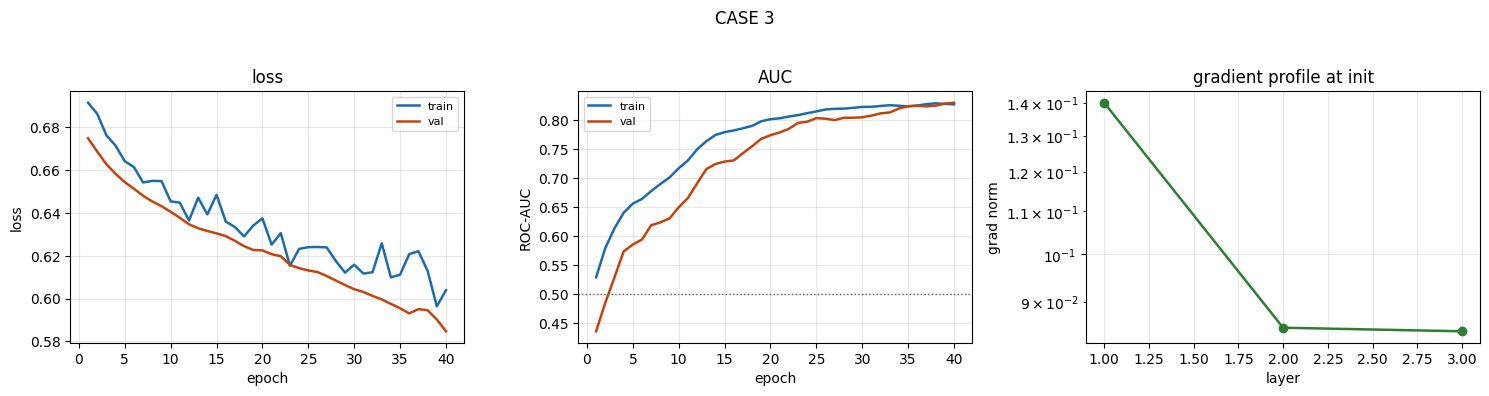

--- Tier 0: case 3 ---
  final train loss / val loss : 0.6039 / 0.5847
  finite?                     : True
  final val AUC               : 0.8295   (chance = 0.5000)
  best  val AUC               : 0.8295
  final val accuracy          : 0.7000   (majority = 0.7000)
  predictions: min 0.2769  max 0.4165  std 3.330e-02  distinct 220
  grad ratio last/first       : 6.020e-01


In [11]:
case3 = run_experiment({**BASELINE, "name": "case3", "hidden": (16, 8),
                        "dropout": 0.8, "weight_decay": 1.0})
show(case3, "CASE 3")
tier0(case3, "case 3")


**Evidence.** The loss curves are calm and well behaved. Validation AUC is respectable, but validation accuracy is exactly the majority-class rate. Predictions are also concentrated in a narrow middle range and do not cross 0.5.

**Diagnosis.** The model is **over-regularised**. The small architecture, aggressive dropout, and strong weight decay collectively restrict the model so much that it can retain some ability to **rank** examples without producing sufficiently separated probabilities for threshold-based decisions.

To understand this, separate two ideas:

- **Ranking:** are positive examples generally assigned higher scores than negative examples? AUC measures this.
- **Classification at a threshold:** after choosing a threshold such as 0.5, how many examples are labelled positive or negative? Accuracy depends on this decision rule.

AUC is therefore threshold-free. A model can rank examples reasonably well while leaving every probability below the chosen classification threshold. In that situation, AUC can look good while threshold-based accuracy remains at the majority-class baseline.

**The trap.** Looking only at AUC would make this model appear successful. Looking only at the loss would also miss the problem. The useful diagnosis comes from combining **AUC + accuracy + prediction range**.

**How to catch it.** If AUC is respectable but accuracy equals the majority-class rate and the predictions are tightly clustered, investigate whether regularisation or capacity is preventing the model from separating the classes strongly enough.

**Fix.** Reduce the regularisation. As Note 3.2 established, first make sure early stopping/checkpoint selection is sensible, then add regularisation only when it measurably improves the relevant validation behaviour.

In [12]:
fix3 = run_experiment({**BASELINE, "name": "case3_fixed", "hidden": (16, 8), "dropout": 0.2})
print(f"\n  over-regularised: val AUC {case3['best_val_auc']:.4f}  "
      f"acc {case3['final']['val_acc']:.4f}  pred range [{case3['pred_min']:.3f}, {case3['pred_max']:.3f}]")
print(f"  fixed           : val AUC {fix3['best_val_auc']:.4f}  "
      f"acc {fix3['final']['val_acc']:.4f}  pred range [{fix3['pred_min']:.3f}, {fix3['pred_max']:.3f}]")
print(f"  majority-class accuracy: {case3['majority_acc']:.4f}")


[case3_fixed] german_credit  0.6s   final val AUC 0.8093   best val AUC 0.8247

  over-regularised: val AUC 0.8295  acc 0.7000  pred range [0.277, 0.417]
  fixed           : val AUC 0.8247  acc 0.7360  pred range [0.001, 0.827]
  majority-class accuracy: 0.7000


**Check your understanding**

1. Case 3 has the highest validation AUC in this notebook, 0.8295, above the reference's 0.8158. Why does that number alone fail to establish that the model is useful?
2. Validation accuracy is 0.7000 and the majority-class rate is 0.7000. What does that imply about the thresholded predictions on this validation set?
3. Name two additional measurements that reveal the problem that AUC misses. For each, state what pattern you would expect from a healthy model.

<a id="s7"></a>
## 7. Case 4 — broken validation

The first three cases were failures of the **model or training configuration**. This case is different: the model may be behaving exactly as instructed, but the experiment has invalid evaluation data.

That distinction is fundamental.

A model is evaluated by comparing its predictions with outcomes on data that represents the situation in which the model will be used. If information from the training set leaks into validation, the validation score no longer estimates performance on genuinely unseen data.

The result can look excellent precisely because the evaluation has stopped being independent.

[case4] german_credit  0.6s   final val AUC 1.0000   best val AUC 1.0000


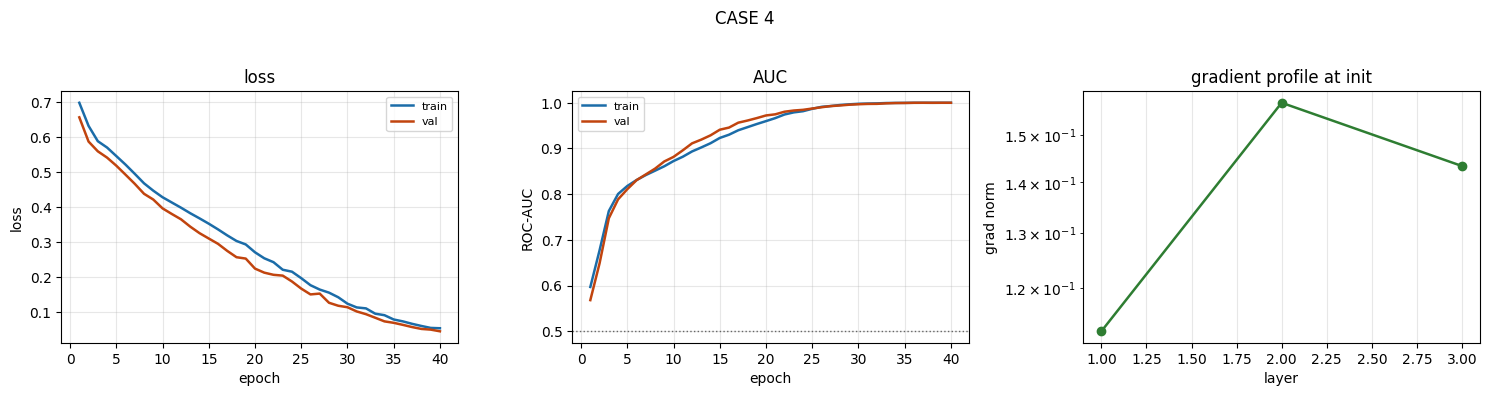

--- Tier 0: case 4 ---
  final train loss / val loss : 0.0551 / 0.0464
  finite?                     : True
  final val AUC               : 1.0000   (chance = 0.5000)
  best  val AUC               : 1.0000
  final val accuracy          : 1.0000   (majority = 0.7200)
  predictions: min 0.0000  max 1.0000  std 4.109e-01  distinct 190
  grad ratio last/first       : 1.274e+00

  reference val AUC : 0.7245
  case 4   val AUC  : 1.0000
  train AUC         : 1.0000
  val AUC - train AUC gap: +0.0000


In [13]:
case4 = run_experiment({**BASELINE, "name": "case4", "leak_split": True})
show(case4, "CASE 4")
tier0(case4, "case 4")
print()
print(f"  reference val AUC : {ref['final']['val_auc']:.4f}")
print(f"  case 4   val AUC  : {case4['final']['val_auc']:.4f}")
print(f"  train AUC         : {case4['final']['train_auc']:.4f}")
print(f"  val AUC - train AUC gap: {case4['final']['val_auc'] - case4['final']['train_auc']:+.4f}")


**Evidence.** The validation curve tracks the training curve almost exactly. There is effectively no generalisation gap. On the 500-row dataset used here, that is suspicious because the model can reach a training AUC of 1.0 while a genuinely unseen validation set should not simply reproduce the same behaviour.

The validation AUC is also far above the reference run.

**Diagnosis.** The validation rows are drawn from the training rows. The model is therefore being evaluated on examples it has already seen during training. The label "validation" does not make those rows independent.

This is **validation leakage**: information that should be held out for evaluation has become available to the training process.

**Why this is especially dangerous.** Cases 1–3 produce poor or limited numbers, which naturally invite investigation. A broken validation split can produce a *beautiful* number. That makes the bug more likely to survive review and reach deployment.

### More realistic forms of validation leakage

The exact bug here is blatant, but real projects often leak information in subtler ways:

- duplicate records are removed only after the split, allowing duplicates into both sets;
- rows from the same customer or patient are randomly split, so the same entity appears on both sides;
- time-series rows are randomly split, allowing the model to train on information from the future;
- preprocessing statistics are fitted on the full dataset before splitting.

The last case explains the common pipeline pattern:

```python
pre.fit_transform(X_train)
pre.transform(X_val)
```

The preprocessing object learns its parameters from training data only. Validation data is transformed using those already-learned parameters.

**The tell.** A validation score that is suspiciously close to, or even better than, training performance deserves an investigation of the split and data flow. A small generalisation gap can be perfectly normal; the point is not that every small gap is leakage, but that an implausibly perfect evaluation should be explained.

**Fix.** Rebuild the split so that validation examples are genuinely held out. Where rows have a natural group structure, split by the group rather than by individual row.

**Check your understanding**

1. Validation AUC is exactly 1.0000 and the validation-minus-training gap is +0.0000. Which observation is the stronger *diagnostic clue* that the split is broken, and why is the combination more informative than either number alone?
2. This notebook uses a blunt leak: validation rows are copied from training rows. How would you investigate the subtler case where rows are distinct but several rows belong to the same customer?
3. Suppose the leak were less obvious and the validation-minus-training gap were −0.02 instead of 0.0000. What would you inspect before deciding that the split is sound?

<a id="s8"></a>
## 8. Case 5 — poor initialisation

A neural network does not begin from a neutral state. Its initial parameter values determine the numerical scale of the first forward pass and therefore the scale of the first backward pass.

Good initialisation aims to keep activations and gradients in a useful numerical range. Poor initialisation can put the network into an extreme state before learning has meaningfully begun.

This case makes that visible by deliberately starting with weights that are far too large.

[case5] german_credit  0.6s   final val AUC 0.6024   best val AUC 0.6029


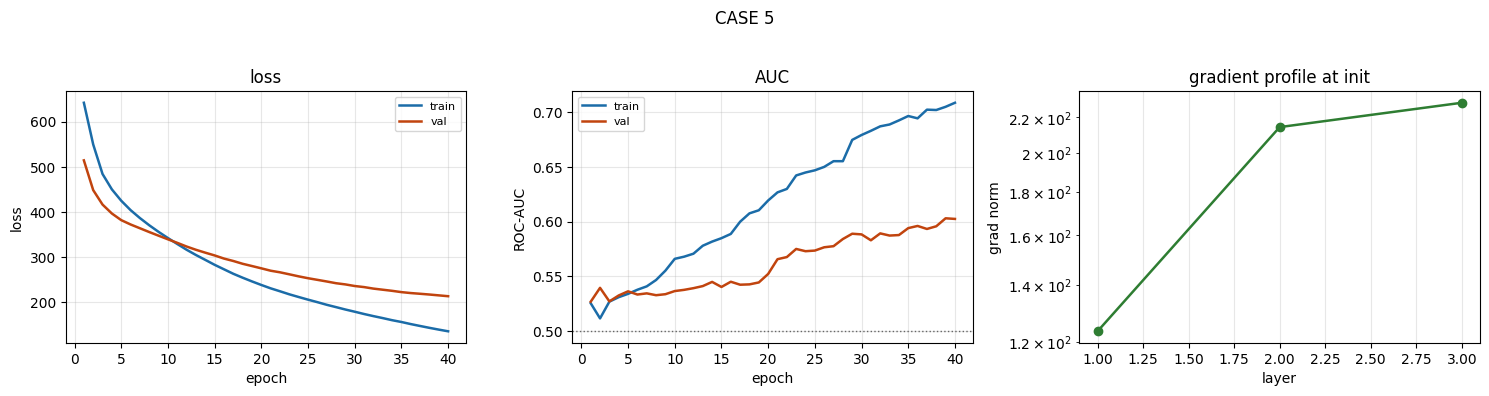

--- Tier 0: case 5 ---
  final train loss / val loss : 135.0999 / 212.8671
  finite?                     : True
  final val AUC               : 0.6024   (chance = 0.5000)
  best  val AUC               : 0.6029
  final val accuracy          : 0.6400   (majority = 0.7000)
  predictions: min 0.0000  max 1.0000  std 4.643e-01  distinct 7
  grad ratio last/first       : 1.851e+00

  gradient norms at initialisation, per layer:
    0.weight     1.2359e+02
    2.weight     2.1428e+02
    4.weight     2.2881e+02
  reference, same layers:
    0.weight     1.1257e-01
    2.weight     1.5730e-01
    4.weight     1.4339e-01


In [14]:
case5 = run_experiment({**BASELINE, "name": "case5", "init": "big", "init_std": 3.0})
show(case5, "CASE 5")
tier0(case5, "case 5")
print()
print("  gradient norms at initialisation, per layer:")
for k, v in case5["grads_at_start"].items():
    print(f"    {k:<12} {v:.4e}")
print(f"  reference, same layers:")
for k, v in ref["grads_at_start"].items():
    print(f"    {k:<12} {v:.4e}")


**Evidence.** The first loss is in the hundreds rather than near the roughly 0.6–0.7 range expected for a sensibly initialised binary classifier whose initial predictions are near the dataset base rate. The initial gradient norms are also orders of magnitude larger than those in the reference run.

The loss decreases, but never reaches a reasonable region, and AUC remains poor — below both the reference run and the logistic-regression baseline.

**Diagnosis.** The weights were initialised far too large. As discussed in Note 3.3, oversized weights create oversized pre-activations. That pushes the network into an extreme numerical regime and can produce very large gradients and unstable updates. The optimiser then spends the run trying to recover from a poor starting scale.

**The Tier 0 tell that costs almost nothing.** For a binary classifier whose initial predictions are close to the base rate `p`, binary cross-entropy should be near the entropy of that base-rate prediction:

```text
-[p·ln(p) + (1-p)·ln(1-p)]
```

For this dataset that is around 0.6. The exact number is not the point; the diagnostic principle is.

If the **first** loss is wildly outside a plausible range, investigate initialisation and input scaling before spending time tuning later training behaviour. The first forward pass is a cheap window into whether the model started in a sensible numerical regime.

In [15]:
p = float(ref["history"][0]["train_loss"])
base = 0.30                                       # positive rate in German Credit
expected = -(base*np.log(base) + (1-base)*np.log(1-base))
print(f"  expected initial loss for base rate {base}: {expected:.4f}")
print(f"  reference, epoch-1 train loss            : {ref['history'][0]['train_loss']:.4f}   <- sane")
print(f"  case 5,    epoch-1 train loss            : {case5['history'][0]['train_loss']:.4f}   <- not sane")
print()
fix5 = run_experiment({**BASELINE, "name": "case5_fixed", "init": "default"})
print(f"\n  broken init: val AUC {case5['final']['val_auc']:.4f}")
print(f"  default init: val AUC {fix5['final']['val_auc']:.4f}")


  expected initial loss for base rate 0.3: 0.6109
  reference, epoch-1 train loss            : 0.6975   <- sane
  case 5,    epoch-1 train loss            : 641.6535   <- not sane



[case5_fixed] german_credit  0.6s   final val AUC 0.7245   best val AUC 0.8158

  broken init: val AUC 0.6024
  default init: val AUC 0.7245


**Check your understanding**

1. The epoch-1 training loss is 641.65 against an expected value around 0.61 for the dataset base rate. Why is the first loss a more useful clue about initialisation than the final loss?
2. Initial gradient norms are around `1e+02` per layer versus roughly `1e-01` in the reference. Which Note 3.3 pathology does this pattern suggest, and why?
3. This case produces 7 distinct predictions spanning nearly the full 0–1 range. How does that differ from Case 1's near-constant prediction collapse, and what does that difference tell you about the underlying failure?

<a id="s9"></a>
## 9. Case 6 — the one that looks fine

Every previous case had an obvious statistical or optimisation symptom.

This one is different.

The curves are healthy. The gradient profile is healthy. The generalisation gap looks normal. Predictions are well spread. The model appears excellent.

And the model is still unusable.

This is the case that forces you to recognise a boundary of model diagnostics: **some failures cannot be discovered by looking at the training run alone.** You must understand what the features mean and when they exist in the real process.

[case6] bank_marketing  4.3s   final val AUC 0.9262   best val AUC 0.9264


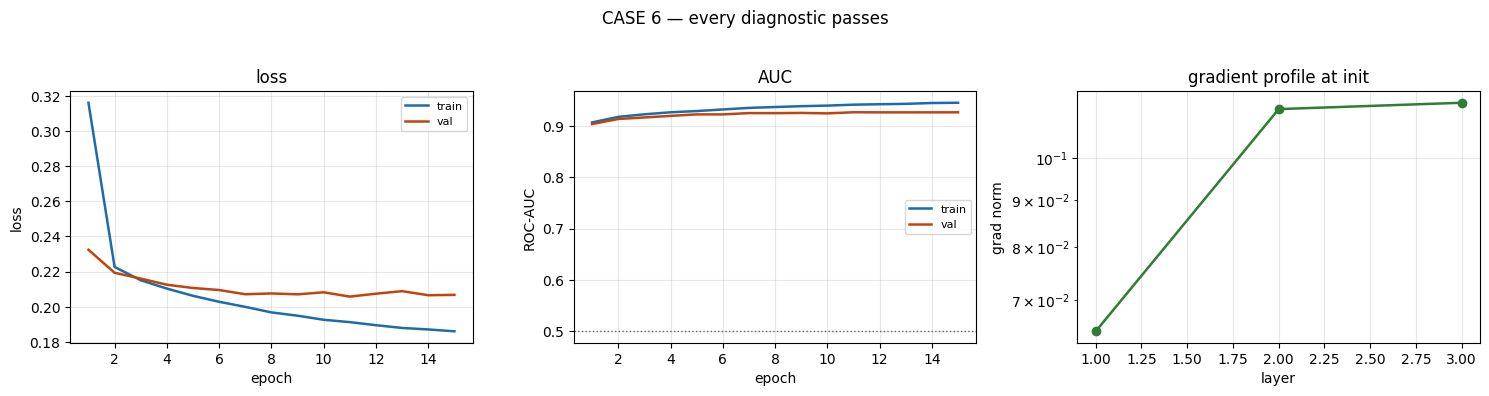

--- Tier 0: case 6 ---
  final train loss / val loss : 0.1860 / 0.2067
  finite?                     : True
  final val AUC               : 0.9262   (chance = 0.5000)
  best  val AUC               : 0.9264
  final val accuracy          : 0.9078   (majority = 0.8830)
  predictions: min 0.0000  max 0.9265  std 2.108e-01  distinct 1681
  grad ratio last/first       : 1.777e+00



[case6_clean] bank_marketing  4.2s   final val AUC 0.7853   best val AUC 0.7853

  with `duration`   : val AUC 0.9262
  without `duration`: val AUC 0.7853
  logistic-regression baseline (Note 3.1): 0.7717
  improvement from one column: +0.1409 AUC


In [16]:
case6 = run_experiment({**BASELINE, "name": "case6", "dataset": "bank_marketing",
                        "include_duration": True, "batch_size": 256, "epochs": 15})
show(case6, "CASE 6 — every diagnostic passes")
tier0(case6, "case 6")
print()
clean = run_experiment({**BASELINE, "name": "case6_clean", "dataset": "bank_marketing",
                        "include_duration": False, "batch_size": 256, "epochs": 15})
print(f"\n  with `duration`   : val AUC {case6['final']['val_auc']:.4f}")
print(f"  without `duration`: val AUC {clean['final']['val_auc']:.4f}")
print(f"  logistic-regression baseline (Note 3.1): 0.7717")
print(f"  improvement from one column: {case6['final']['val_auc'] - clean['final']['val_auc']:+.4f} AUC")


**Evidence.** There is no obvious internal failure. Every Tier 0 and Tier 1 diagnostic passes. The curves match gallery shape A, gradients are well behaved, predictions are well spread, and the generalisation gap is small and stable.

The only statistical warning is Tier 0 check 4: the result is much better than a sensible baseline and there is no credible explanation for the size of the improvement.

**Diagnosis.** The problem is the `duration` feature. It records how long the sales call lasted. Call duration is strongly related to whether the call ultimately succeeds, so it is highly predictive inside the historical dataset.

But the prediction is supposed to answer a question such as **"who should we call?"** At the moment that decision must be made, the call has not happened yet. Therefore `duration` does not exist.

This is **target leakage**: an input contains information that is available only because the outcome, or a process downstream of the outcome, has already occurred.

That makes this different from validation leakage:

- **Validation leakage** contaminates the separation between training and evaluation data.
- **Target leakage** uses an input feature that would not be available at the real prediction time.

### Why ordinary statistical diagnostics cannot catch this

Within the historical table, `duration` is simply a very good predictor. Cross-validation can repeatedly confirm that it is predictive. The problem is not that the statistical relationship is false.

The problem is that the relationship is **temporally invalid for deployment**.

This means leakage is partly a data-science problem and partly a domain-understanding problem. A person has to know where each feature comes from and when it becomes available.

### The three questions that catch it

For every feature, ask:

1. **At the moment I need to make the prediction, does this value exist yet?**
2. **Could this value have been influenced by the outcome I am trying to predict?**
3. **If I deployed the model tomorrow, could I actually obtain this value in time?**

A result that is dramatically better than a sensible baseline should therefore be treated as an **investigation trigger**, not automatically as a success.

<div align="center">

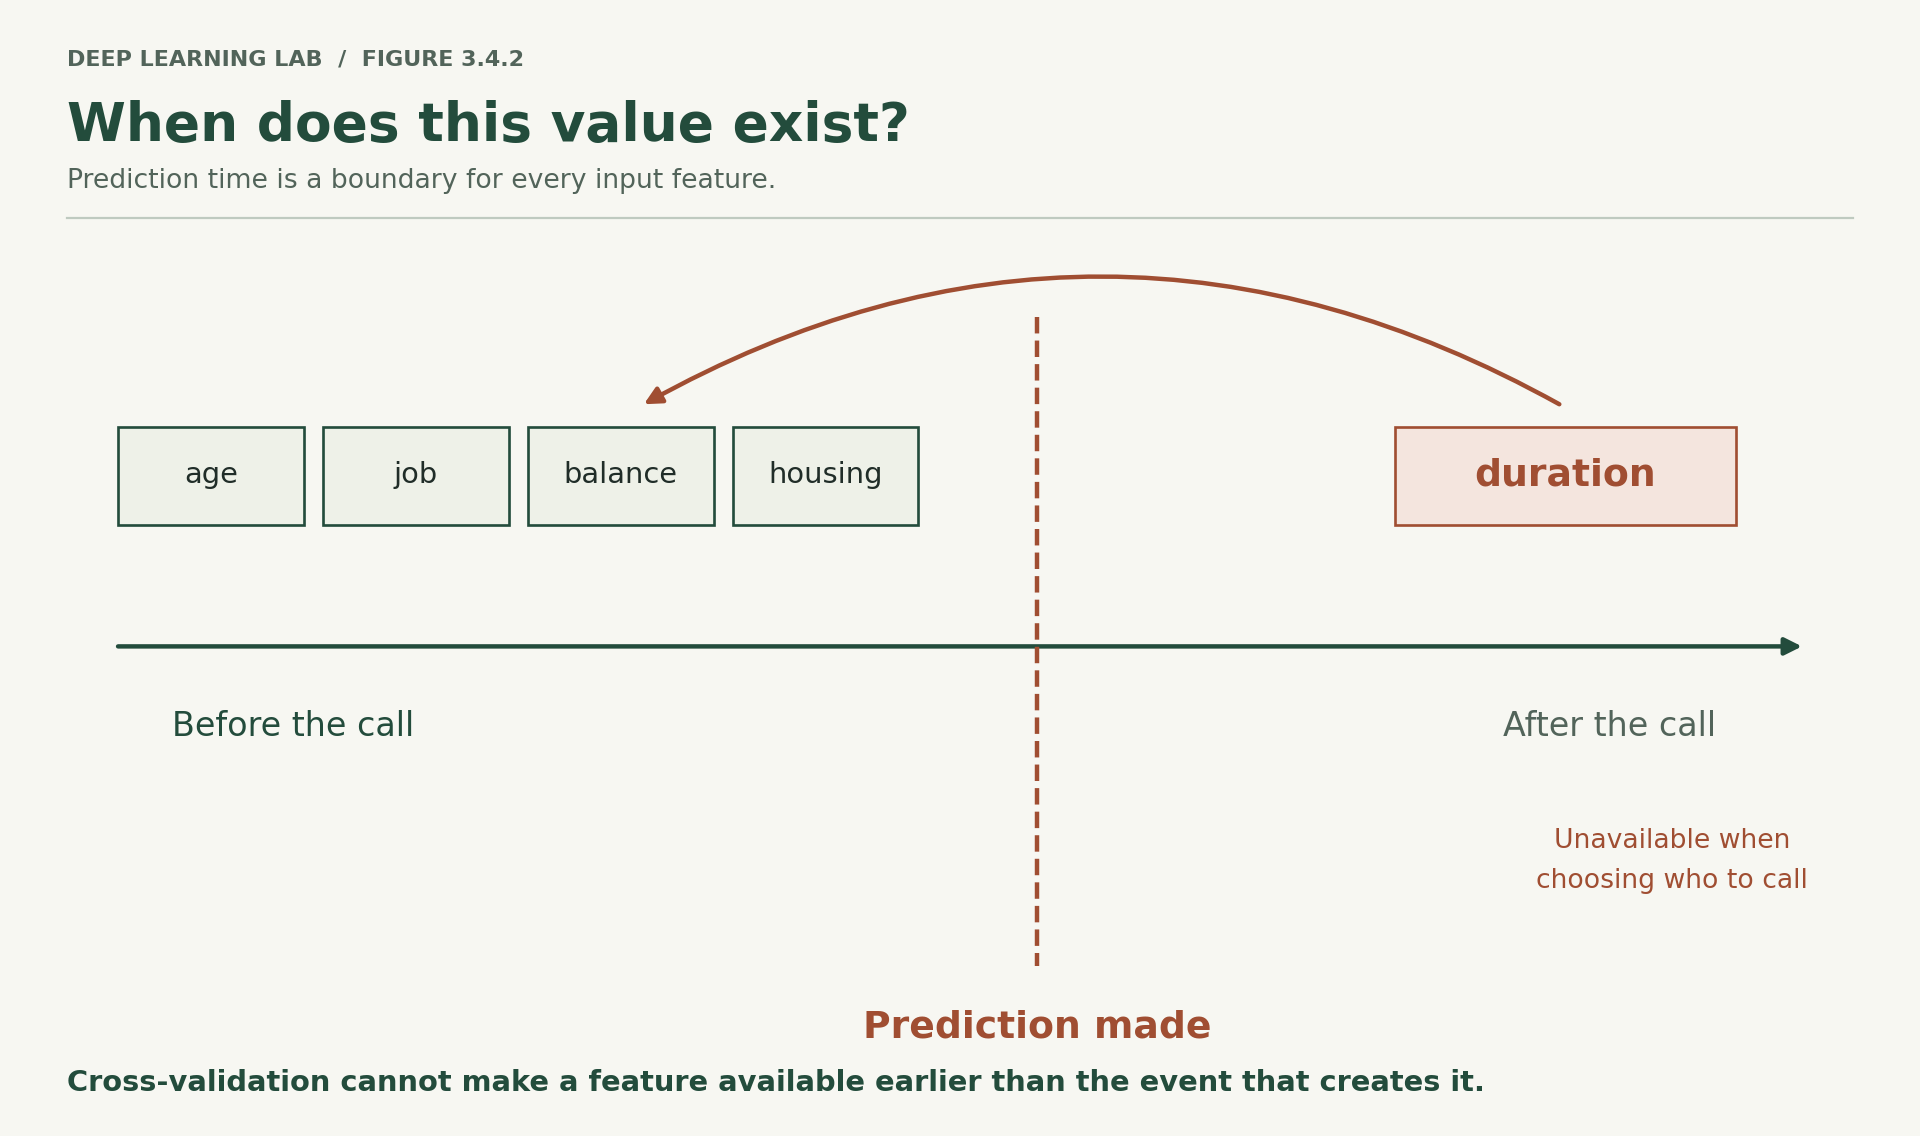

<p><b>Figure 3.4.2.</b> Call duration is predictive in a historical table but unavailable when deciding who to call. The violation is about feature availability at prediction time.</p>

</div>

**Check your understanding**

1. Every Tier 0 and Tier 1 check passes on Case 6. Which protocol check fires, and what does it compare the result against?
2. `duration` adds about +0.1409 AUC relative to the same model without it. Why would cross-validation still fail to identify this as invalid?
3. Apply the three leakage questions to `campaign` (number of contacts during this campaign) and `poutcome` (outcome of the previous campaign). What information would you need to decide whether either feature is valid at prediction time?
4. A colleague reports a model that beats your baseline by 0.14 AUC. What are the first two questions you would ask before treating the improvement as genuine?

<a id="s10"></a>
## 10. Your turn

Now the answer key disappears.

There are two configurations below. For each one:

1. run the experiment;
2. inspect the curve and Tier 0 output;
3. work through the protocol from Section 3 in order;
4. write the **evidence** before writing the diagnosis;
5. propose the smallest defensible fix;
6. run the fix and check whether the result changes in the way your hypothesis predicted.

Resist the urge to guess and immediately re-run. The point of the exercise is to practise **evidence → hypothesis → test**, not trial-and-error tuning.

A note about Mystery B: it contains **more than one fault**. That means you will need to distinguish the primary symptoms and avoid stopping after finding the first plausible explanation.

Run these, then diagnose. The Tier 0 helper and `show()` are already defined.



[mystery_a] german_credit  1.8s   final val AUC 0.7073   best val AUC 0.8359


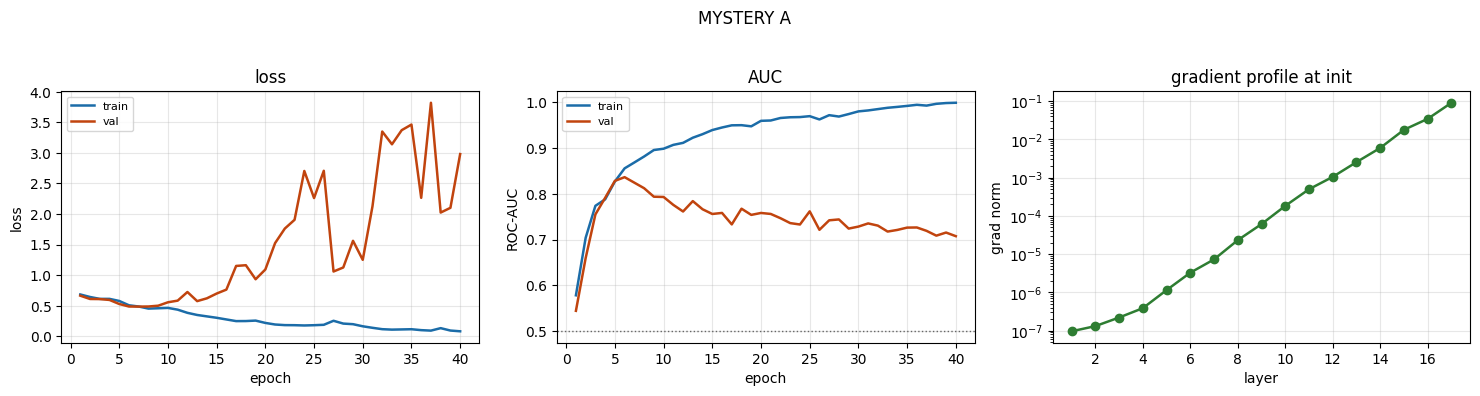

--- Tier 0: mystery A ---
  final train loss / val loss : 0.0828 / 2.9797
  finite?                     : True
  final val AUC               : 0.7073   (chance = 0.5000)
  best  val AUC               : 0.8359
  final val accuracy          : 0.6880   (majority = 0.7000)
  predictions: min 0.0000  max 0.9951  std 3.807e-01  distinct 107
  grad ratio last/first       : 9.466e+05


In [17]:
mystery_a = {**BASELINE, "name": "mystery_a", "hidden": tuple([64]*16),
             "lr": 1e-3, "epochs": 40}
mystery_b = {**BASELINE, "name": "mystery_b", "hidden": (256, 128), "lr": 1e-4,
             "weight_decay": 2.0, "dropout": 0.6, "epochs": 25}

print("Run these, then diagnose. The Tier 0 helper and `show()` are already defined.\n")
ma = run_experiment(mystery_a); show(ma, "MYSTERY A"); tier0(ma, "mystery A")


[mystery_b] german_credit  0.6s   final val AUC 0.8048   best val AUC 0.8048


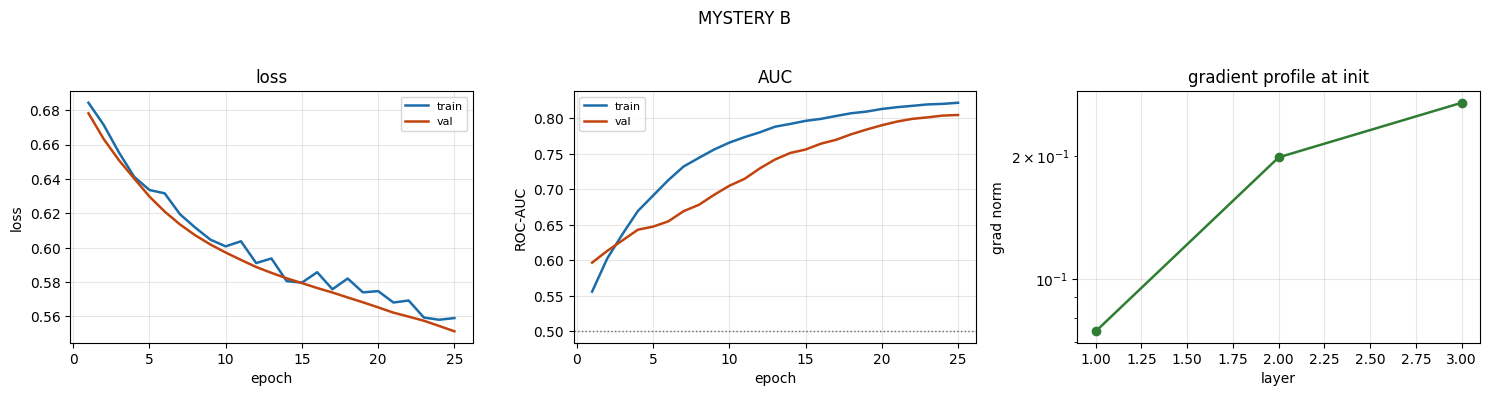

--- Tier 0: mystery B ---
  final train loss / val loss : 0.5591 / 0.5514
  finite?                     : True
  final val AUC               : 0.8048   (chance = 0.5000)
  best  val AUC               : 0.8048
  final val accuracy          : 0.7000   (majority = 0.7000)
  predictions: min 0.1329  max 0.4340  std 6.295e-02  distinct 232
  grad ratio last/first       : 3.634e+00


In [18]:
mb = run_experiment(mystery_b); show(mb, "MYSTERY B"); tier0(mb, "mystery B")


In [19]:
# Scratch space for your diagnosis.
#
# MYSTERY A
#   evidence   :
#   diagnosis  :
#   proposed fix:
#
# MYSTERY B
#   evidence   :
#   diagnosis  :
#   proposed fix:
#
# Test your fixes by editing a copy of the config and re-running, e.g.:
# fix_a = run_experiment({**mystery_a, "name": "mystery_a_fixed", "lr": ...})
# tier0(fix_a, "mystery A fixed")

print("Hints, if you need them:")
print("  A — compare the gradient profile panel against the reference run's.")
print("      Then count the layers. Then look at what Note 3.3 sections 3, 6 and 7 were about.")
print("  B — check the AUC and the accuracy separately, then the prediction range.")
print("      Then ask whether the run has plateaued. Two things are wrong, not one.")


Hints, if you need them:
  A — compare the gradient profile panel against the reference run's.
      Then count the layers. Then look at what Note 3.3 sections 3, 6 and 7 were about.
  B — check the AUC and the accuracy separately, then the prediction range.
      Then ask whether the run has plateaued. Two things are wrong, not one.


<a id="s11"></a>
## 11. Writing it up

A diagnosis that cannot be reconstructed three months later is of limited value. The point of an experiment record is not bureaucracy; it is to preserve the reasoning that connects a configuration to an observed result.

The blueprint makes documentation a cross-cutting practice for exactly this reason, and Day 4 will turn it into a formal experiment protocol.

The format below is deliberately minimal. It captures five questions:

1. **What did I try?**
2. **Why did I try it?**
3. **What happened?**
4. **What did I learn?**
5. **What would I change next?**

The log also records the configuration differences from the baseline. That makes the experiment easier to reproduce and makes the causal comparison visible without forcing you to copy a large configuration block every time.

A good record should let your future self reconstruct the reasoning without needing to trust your memory.

In [20]:
def experiment_log(result, hypothesis, diagnosis, action, learned):
    """Emit a markdown experiment record next to the JSON results."""
    cfg = result["config"]; f = result["final"]
    changed = {k: v for k, v in cfg.items()
               if k not in BASELINE or BASELINE.get(k) != v}
    md_text = f"""### Experiment: {cfg.get('name','run')}

**Date/run time:** {result['seconds']:.1f}s on {cfg.get('dataset','german_credit')}

**Changed from baseline:** {changed or 'nothing'}

**Hypothesis:** {hypothesis}

**Result:** final val AUC {f['val_auc']:.4f} (best {result['best_val_auc']:.4f}),
val accuracy {f['val_acc']:.4f} against majority {result['majority_acc']:.4f},
predictions in [{result['pred_min']:.3f}, {result['pred_max']:.3f}]
with {result['n_unique_preds']} distinct values,
gradient ratio {result['grad_ratio']:.2e}

**Diagnosis:** {diagnosis}

**Action taken:** {action}

**What I learned:** {learned}
"""
    path = f"results/{cfg.get('name','run')}.md"
    with open(path, "w") as fh: fh.write(md_text)
    print(md_text)
    return path

experiment_log(
    case1,
    hypothesis="A higher learning rate would converge faster than the 1e-3 baseline.",
    diagnosis=("Collapsed to a constant predictor. Val AUC exactly 0.5000, one distinct "
               "prediction across the validation set, accuracy equal to the majority rate. "
               "Loss was flat and stable, which initially looked like convergence."),
    action="Reverted to lr=1e-3. Confirmed recovery: val AUC returned to the reference level.",
    learned=("A flat loss is not evidence of convergence. The prediction-spread check in Tier 0 "
             "identified this in under a second, without retraining."))


### Experiment: case1

**Date/run time:** 0.6s on german_credit

**Changed from baseline:** {'name': 'case1', 'lr': 0.5}

**Hypothesis:** A higher learning rate would converge faster than the 1e-3 baseline.

**Result:** final val AUC 0.5029 (best 0.5134),
val accuracy 0.7000 against majority 0.7000,
predictions in [0.202, 0.351]
with 2 distinct values,
gradient ratio 1.27e+00

**Diagnosis:** Collapsed to a constant predictor. Val AUC exactly 0.5000, one distinct prediction across the validation set, accuracy equal to the majority rate. Loss was flat and stable, which initially looked like convergence.

**Action taken:** Reverted to lr=1e-3. Confirmed recovery: val AUC returned to the reference level.

**What I learned:** A flat loss is not evidence of convergence. The prediction-spread check in Tier 0 identified this in under a second, without retraining.



'results/case1.md'

In [21]:
print("files written by this notebook:")
for fn in sorted(os.listdir("results")):
    print(f"  results/{fn}")
print()
print("The JSON files carry the full history and gradient profile for every run,")
print("so any of these can be re-plotted or compared later without retraining.")


files written by this notebook:
  results/baseline.json
  results/case1.json
  results/case1.md
  results/case1_fixed.json
  results/case2.json
  results/case2_fixed.json
  results/case3.json
  results/case3_fixed.json
  results/case4.json
  results/case5.json
  results/case5_fixed.json
  results/case6.json
  results/case6_clean.json
  results/mystery_a.json
  results/mystery_b.json

The JSON files carry the full history and gradient profile for every run,
so any of these can be re-plotted or compared later without retraining.


**Check your understanding**

1. The record separates the hypothesis from the diagnosis. Why does writing the hypothesis **before** the run change what you can learn from the result?
2. The log stores the configuration keys that differ from the baseline rather than the entire configuration. What does that make easier to read and compare, and what information might you lose?
3. Choose any case in this notebook and reconstruct its record in four sentences without looking back at the diagnosis text. Which part is hardest to reconstruct? That difficulty is evidence about what you should have written down during the experiment.

### What to take away

**Diagnose before you intervene.** Changing something plausible and re-running is search, not diagnosis. It can find a working configuration while teaching you very little about the original failure.

**Order checks by cost.** Tier 0 checks — finite losses, metrics, prediction spread, majority-class comparison, and baseline plausibility — cost almost nothing. Use them before spending another training cycle.

**The loss is evidence, not the diagnosis.** A flat loss can mean healthy convergence or collapse. A smooth descending loss can mean genuine progress or simply that the run has not trained long enough. Always read the loss alongside metrics, predictions, and the reference run.

**Use prediction behaviour as a first-class diagnostic.** A model that emits nearly one value has a very different problem from a model whose predictions are spread across the full range. The metric alone may not reveal that distinction.

**The tiny-subset overfit test is a powerful structural check.** If the model cannot memorise a tiny set of examples when deliberately given enough optimisation, suspect the model, data pipeline, or loss before tuning ordinary hyperparameters.

**Good numbers deserve scrutiny too.** A broken validation split can produce excellent validation scores. A leaked feature can produce excellent curves and healthy gradients. Statistical diagnostics cannot replace knowledge of how the data was generated and when each feature becomes available.

**Write the reasoning down while it is fresh.** A short experiment record turns a training run into reusable knowledge rather than another result you will have to rediscover later.

### Where Day 3 leaves you

You began the day able to write a training loop. You can now:

- choose an optimiser and learning rate with a reason, and identify a sensible learning-rate scale;
- recognise common learning-rate and loss-curve signatures;
- deliberately create overfitting and choose an intervention based on evidence;
- distinguish a genuine improvement from variation by measuring the relevant noise;
- inspect a network's gradient profile layer by layer;
- identify and explain vanishing gradients, exploding gradients, and dead units;
- work from an unfamiliar symptom to a testable diagnosis and then to a defensible intervention.

That is the Day 3 competency the blueprint asks for:

> **Explain why a training run is failing and propose a technically defensible intervention.**

### Transition to Day 4

Day 3 has focused on making a **single run** work and understanding why it behaves as it does.

Day 4 asks the harder experimental question: how do you run **multiple experiments** so that the conclusions remain defensible when someone challenges them?

The foundations are already visible here. Note 3.2 §9 measured a noise floor and showed that many small differences were indistinguishable. Case 4 showed how a broken split can manufacture a beautiful result. This notebook's config runner already writes structured results to disk, which is the beginning of experiment tracking.

Day 4 turns those ideas into a broader discipline:

- controlled comparisons;
- reproducibility;
- leakage prevention;
- GPU memory and mixed precision;
- and a gradient-boosting versus neural-network comparison in which the neural network is not assumed to win.

The goal is not to make one model look good. It is to make **experimental conclusions you can defend**.